In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


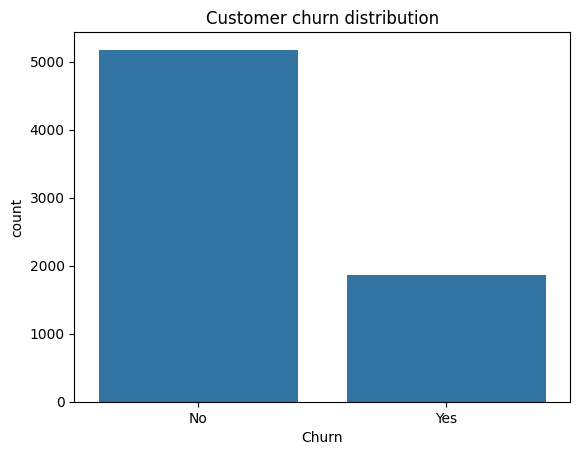

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
sns.countplot(x='Churn', data=df)
plt.title("Customer churn distribution")
plt.show()
print(df['Churn'].value_counts(normalize=True)*100)

In [10]:
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('models', exist_ok=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Missing values before cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.dropna().copy()
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print('Shape after cleaning:', df.shape)


Missing values before cleaning:


TotalCharges    11
dtype: int64
Shape after cleaning: (7032, 21)


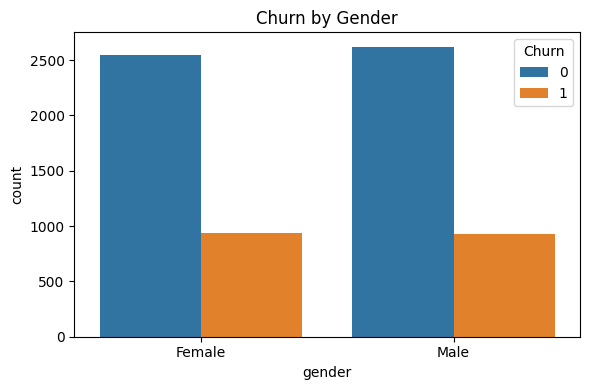

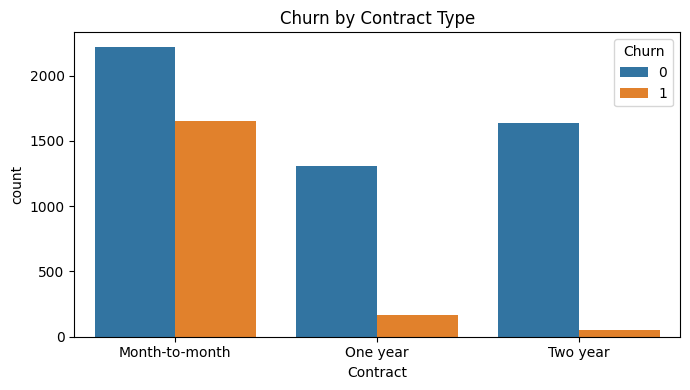

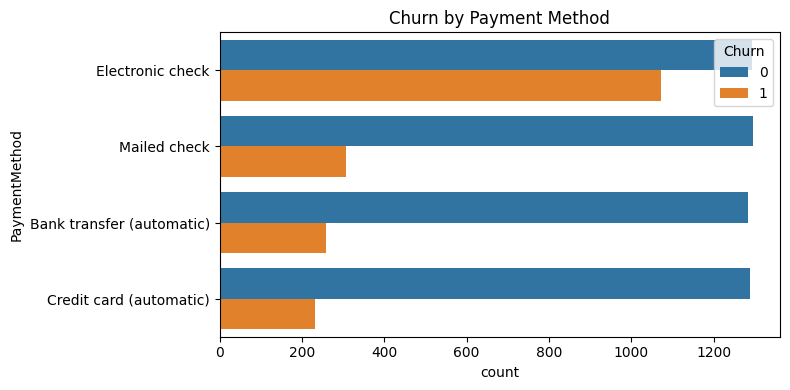

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Churn by Gender')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method')
plt.tight_layout()
plt.show()


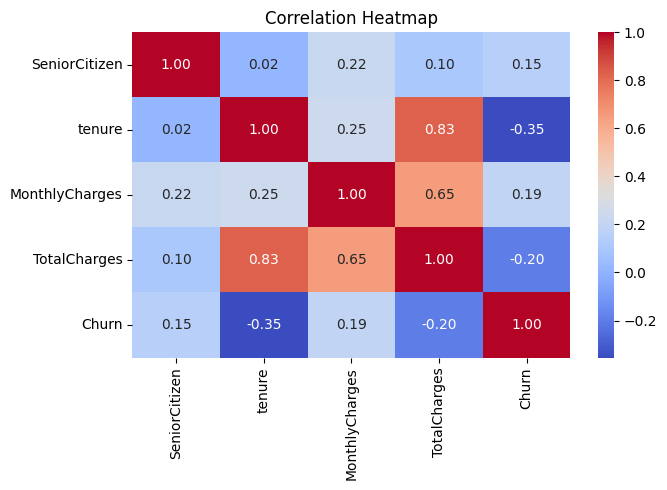

In [12]:
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [13]:
model_df = df.drop(columns=['customerID']).copy()

y = model_df['Churn']
X = model_df.drop(columns=['Churn'])

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
import joblib
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
encoder_all = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

scaler_all = StandardScaler()
categorical_cols = [col for col in X.columns if col not in numeric_cols]

preprocessor_all = ColumnTransformer([
    ('num', scaler_all, numeric_cols),
    ('cat', encoder_all, categorical_cols)
])

X_train_all = preprocessor_all.fit_transform(X_train)
X_test_all = preprocessor_all.transform(X_test)

feature_names_all = preprocessor_all.get_feature_names_out()

print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_all, y_train)

print('After SMOTE:', pd.Series(y_train_smote).value_counts().to_dict())
print('Train shape before SMOTE:', X_train_all.shape)
print('Train shape after SMOTE:', X_train_smote.shape)


Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {0: 4130, 1: 4130}
Train shape before SMOTE: (5625, 45)
Train shape after SMOTE: (8260, 45)


In [15]:
importance_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
importance_model.fit(X_train_smote, y_train_smote)

encoded_importance = pd.DataFrame({
    'encoded_feature': feature_names_all,
    'importance': importance_model.feature_importances_
}).sort_values('importance', ascending=False)

encoded_importance.head(15)


,encoded_feature,importance
1,num__tenure,0.110243
3,num__TotalCharges,0.107867
2,num__MonthlyCharges,0.095797
36,cat__Contract_Month-to-month,0.086953
18,cat__OnlineSecurity_No,0.053749
43,cat__PaymentMethod_Electronic check,0.052753
27,cat__TechSupport_No,0.041569
38,cat__Contract_Two year,0.032936
16,cat__InternetService_Fiber optic,0.024539
21,cat__OnlineBackup_No,0.022664


In [16]:
def original_feature_name(encoded_name):
    name = encoded_name.split('__', 1)[1]
    for col in X.columns:
        if name == col or name.startswith(col + '_'):
            return col
    return name

feature_importance = encoded_importance.copy()
feature_importance['original_feature'] = feature_importance['encoded_feature'].apply(original_feature_name)

original_importance = (
    feature_importance.groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

selected_features = original_importance.head(10)['original_feature'].tolist()
print('Selected top features:', selected_features)
original_importance.head(12)


Selected top features: ['Contract', 'tenure', 'TotalCharges', 'MonthlyCharges', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']


,original_feature,importance
0,Contract,0.135354
1,tenure,0.110243
2,TotalCharges,0.107867
3,MonthlyCharges,0.095797
4,PaymentMethod,0.091877
5,OnlineSecurity,0.075677
6,TechSupport,0.060253
7,InternetService,0.038718
8,OnlineBackup,0.038084
9,PaperlessBilling,0.034479


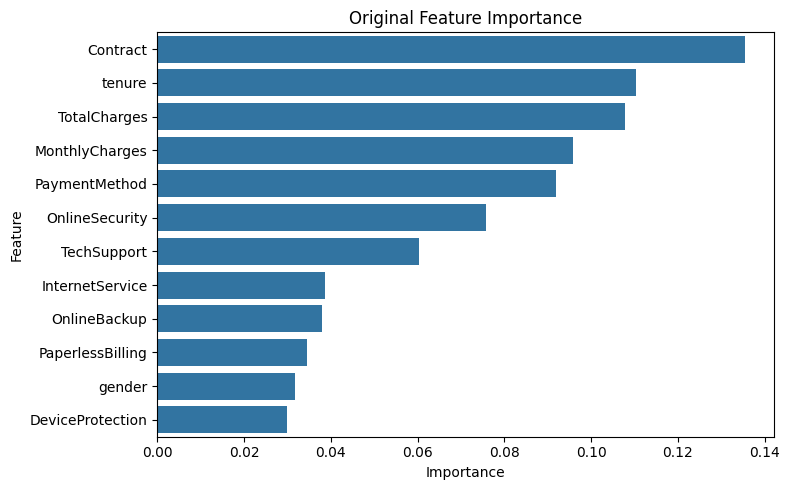

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=original_importance.head(12), x='importance', y='original_feature')
plt.title('Original Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [18]:
X_small = X[selected_features].copy()
selected_numeric = X_small.select_dtypes(exclude='object').columns.tolist()
selected_categorical = X_small.select_dtypes(include='object').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X_small, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer([
    ('num', scaler, selected_numeric),
    ('cat', encoder, selected_categorical)
])

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)
final_feature_names = preprocessor.get_feature_names_out()

X_train_balanced, y_train_balanced = SMOTE(random_state=42).fit_resample(X_train_prepared, y_train)
joblib.dump(preprocessor.named_transformers_['num'], 'models/scaler.pkl')
joblib.dump(preprocessor.named_transformers_['cat'], 'models/encoder.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')
joblib.dump(selected_features, 'models/selected_features.pkl')
joblib.dump(final_feature_names, 'models/final_feature_names.pkl')

print('Selected numeric:', selected_numeric)
print('Selected categorical:', selected_categorical)
print('Prepared train shape:', X_train_prepared.shape)


Selected numeric: ['tenure', 'TotalCharges', 'MonthlyCharges']
Selected categorical: ['Contract', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']
Prepared train shape: (5625, 16)


In [19]:
models = {
    'logistic_regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced', n_jobs=-1)
}

models['xgboost'] = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid={
        'n_estimators': [150, 250],
        'max_depth': [4, 6, None],
        'min_samples_leaf': [1, 3]
    },
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)
rf_grid.fit(X_train_balanced, y_train_balanced)
models['random_forest_tuned'] = rf_grid.best_estimator_
print('Best RF params:', rf_grid.best_params_)


Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 250}


In [20]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    fitted_models[name] = model
    
    preds = model.predict(X_test_prepared)
    probs = model.predict_proba(X_test_prepared)[:, 1] if hasattr(model, 'predict_proba') else preds
    
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, probs)
    })
    
    joblib.dump(model, f'models/{name}.pkl')

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df


,model,accuracy,precision,recall,f1,roc_auc
2,xgboost,0.742715,0.510676,0.767380,0.613248,0.831949
0,logistic_regression,0.726368,0.490939,0.796791,0.607543,0.830598
1,random_forest,0.739872,0.509132,0.596257,0.549261,0.791210
3,random_forest_tuned,0.739872,0.509132,0.596257,0.549261,0.791210


Best model: xgboost
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



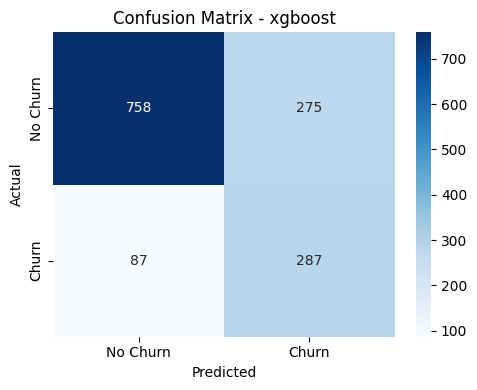

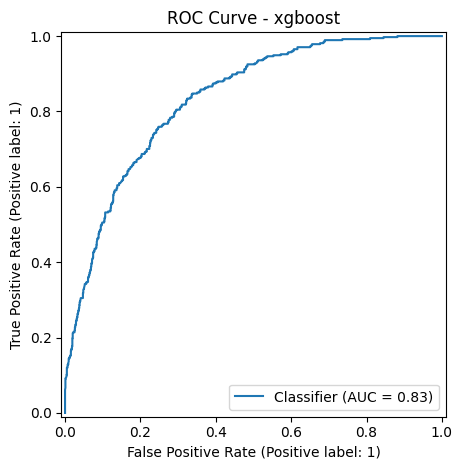

In [21]:
best_model_name = results_df.iloc[0]['model']
best_model = fitted_models[best_model_name]
joblib.dump(best_model, 'models/churn_model.pkl')

print('Best model:', best_model_name)

best_preds = best_model.predict(X_test_prepared)
best_probs = best_model.predict_proba(X_test_prepared)[:, 1] if hasattr(best_model, 'predict_proba') else best_preds

print(classification_report(y_test, best_preds, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, best_probs)
plt.title(f'ROC Curve - {best_model_name}')
plt.tight_layout()
plt.show()


In [22]:
if hasattr(best_model, 'feature_importances_'):
    final_importance = pd.DataFrame({
        'feature': final_feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
else:
    perm = permutation_importance(best_model, X_test_prepared, y_test, n_repeats=10, random_state=42, scoring='roc_auc')
    final_importance = pd.DataFrame({
        'feature': final_feature_names,
        'importance': perm.importances_mean
    }).sort_values('importance', ascending=False)

final_importance.to_csv('models/final_feature_importance.csv', index=False)
final_importance.head(15)


,feature,importance
3,cat__Contract_Month-to-month,0.621337
10,cat__OnlineSecurity_No,0.092450
13,cat__TechSupport_No,0.051977
5,cat__Contract_Two year,0.029617
4,cat__Contract_One year,0.027607
8,cat__PaymentMethod_Electronic check,0.027485
0,num__tenure,0.023456
2,num__MonthlyCharges,0.021999
11,cat__OnlineSecurity_No internet service,0.021206
12,cat__OnlineSecurity_Yes,0.016060


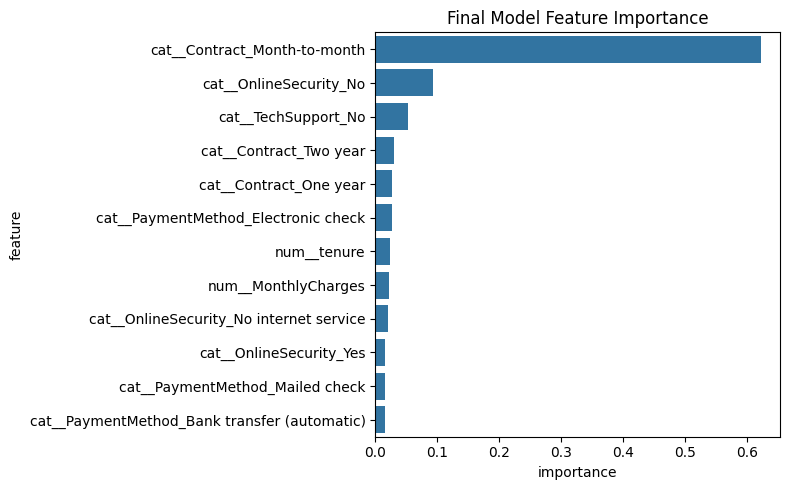

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=final_importance.head(12), x='importance', y='feature')
plt.title('Final Model Feature Importance')
plt.tight_layout()
plt.show()
